In [1]:
import sys
sys.path.append('photon')

In [2]:
import torch
from scipy import ndimage
import torch.nn.functional as F
from data import BeamData, Plan
from models import BeamNet, LaplacianSmoothness2DLoss
import torch.nn as nn
from pathlib import Path
import numpy as np

In [3]:
model = BeamNet()
loss = nn.MSELoss()  # Standard for continuous radiation dose matching
smooth_loss = LaplacianSmoothness2DLoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2, weight_decay=1e-3)

In [4]:
data_dir = Path("/workspace/DoseRAD2026Dev/data/DoseRAD2026/photon/training")

np.random.seed(1234)
pt_list = [f.name for f in data_dir.iterdir() if f.is_dir()]
np.random.shuffle(pt_list)

pt_tr = pt_list[:50]
pt_vl = pt_list[50:60]
pt_ts = pt_list[60:]

# Quick Check

In [5]:
for pt in pt_tr:
    pat_dir = data_dir / pt
    plan = Plan(
        img_file_path=rf"{pat_dir}/image/ct.mha",
        info_json_path=rf"{pat_dir}/{pt}.json",
        dose_dir=rf"{pat_dir}/dose",
    )
    print(pt)

    break

State set to 0
1ABB143


In [6]:
d = BeamData(plan, 30)

Reading dose files: 100%|██████████| 30/30 [00:00<00:00, 30.41it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (30, 129, 252, 276)
Data type: float16


Rotating dose & img: 100%|██████████| 1/1 [00:03<00:00,  3.02s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 1/1 [00:00<00:00,  1.06it/s]


In [7]:
d.plan.isocentre_ijk

(129, 84, 76)

In [1]:
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(275.5), np.float64(251.5), np.float64(-0.5))

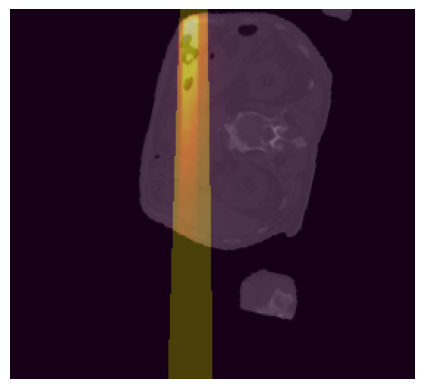

In [9]:
plt.imshow(d.img_rot[8][76], cmap='gray')
plt.imshow(d.bev[8][76], alpha=0.4)
plt.imshow(d.dose[8][76], cmap='hot', alpha=0.3)
plt.axis('off')

In [10]:
d[0][-1].shape

torch.Size([48, 234, 45])

In [11]:
len(d[0])

5

In [43]:
for i in range(100):
    for img, bev, mask, loc, dose in d:

        mask1 = torch.tensor(ndimage.binary_dilation(bev.numpy(), structure=None, iterations=3)).to(int)
        ring1 = (mask1 - bev).bool().cuda()
        mask1 = mask1.bool().cuda()

        img = img.cuda()
        bev = bev.bool().cuda()
        mask = mask.bool().cuda()
        y = dose.cuda()

        pred = model(img, bev, mask)

        l1 = loss(pred[bev], y[bev])
        # l2 = loss(pred[ring1], y[ring1])
        # l3 = loss(pred[~mask1], y[~mask1])
        # l4 = smooth_loss(pred, y)
        # l = l1*2 + l2 + l3 + l4
        l = l1
        
        l.backward()
        optimizer.step()
        optimizer.zero_grad()
        print(l.item())

0.38367047905921936
0.3592025339603424


0.3626863956451416
0.36164137721061707
0.49329090118408203
0.34605494141578674
0.6046509146690369
0.2849266231060028
0.3629699945449829
0.2643614113330841
0.354423850774765
0.37169957160949707
0.3272358477115631
0.2874637544155121
0.45311328768730164
0.4129263758659363
0.3441499173641205
0.2843603491783142
0.34046146273612976
0.3577910363674164
0.40295764803886414
0.33785146474838257
0.35228583216667175
0.6403359770774841
0.2655366063117981
0.30130240321159363
0.3863181173801422
0.2809276282787323
0.39679306745529175
0.2749498784542084
0.3728226125240326
0.3473331332206726
0.36404022574424744
0.3573002517223358
0.5676380395889282
0.34596362709999084
0.5780472755432129
0.31239497661590576
0.39061009883880615
0.2849426865577698
0.356692373752594
0.3327510952949524
0.2812718152999878
0.2537829875946045
0.43388816714286804
0.41484466195106506
0.3153207302093506
0.2751304507255554
0.32188859581947327
0.3454590141773224
0.43674227595329285
0.3501279354095459
0.34463566541671753
0.65049523115

KeyboardInterrupt: 

# First round

In [5]:
model.load_state_dict(torch.load('weights/model_weights_pt_id_0.pth'))

<All keys matched successfully>

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


In [40]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


In [7]:
for pt_id, pt in enumerate(pt_tr):
    pat_dir = data_dir / pt
    plan = Plan(
        img_file_path=rf"{pat_dir}/image/ct.mha",
        info_json_path=rf"{pat_dir}/{pt}.json",
        dose_dir=rf"{pat_dir}/dose",
    )
    d = BeamData(plan, 30)

    for i in range(5):
        for img, bev, mask, loc, dose in d:
        
            mask1 = torch.tensor(ndimage.binary_dilation(bev.numpy(), structure=None, iterations=3)).to(int)
            ring1 = (mask1 - bev).bool().cuda()
            mask1 = mask1.bool().cuda()

            img = img.cuda()
            bev = bev.bool().cuda()
            mask = mask.bool().cuda()
            y = dose.cuda()

            pred = model(img, bev, mask)

            l1 = loss(pred[bev], y[bev])
            # l2 = loss(pred[ring1], y[ring1])
            # l3 = loss(pred[~mask1], y[~mask1])
            # l4 = smooth_loss(pred, y)
            # l = l1*2 + l2 + l3 + l4
            l = l1
            
            l.backward()
            optimizer.step()
            optimizer.zero_grad()
            print(l.item())

    if pt_id % 10 == 0:
        torch.save(model.state_dict(), f'weights/model_weights_pt_id_{pt_id}.pth')



State set to 0


Reading dose files: 100%|██████████| 30/30 [00:02<00:00, 12.54it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (30, 129, 252, 276)
Data type: float16


Rotating dose & img: 100%|██████████| 1/1 [00:02<00:00,  2.96s/it]


Grid created


...

Starting parallel load with 8 threads...

Finished. Final array shape: (30, 153, 250, 270)
Data type: float16


Rotating dose & img: 100%|██████████| 1/1 [00:02<00:00,  2.94s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 1/1 [00:01<00:00,  1.11s/it]


0.3435531556606293
0.56706303358078
0.6825520396232605
0.9555615186691284
0.28388965129852295
0.45261648297309875
0.7196007370948792
0.9766563773155212
0.8298192024230957
0.20682093501091003
0.3267056345939636
0.19054146111011505
1.26520836353302
0.9563165903091431
0.6916933655738831
0.7089880108833313
0.27198004722595215
0.7026770114898682
0.346729040145874
0.2627396881580353
0.5844494104385376
0.46461358666419983
0.5253757834434509
0.42752063274383545
0.6113728284835815
0.5561370849609375
0.35993582010269165
0.6839993000030518
0.48467546701431274
0.41015154123306274
0.27011510729789734
0.5860435962677002
0.538840115070343
0.7473904490470886
0.23565678298473358
0.44597309827804565
0.32437729835510254
0.45365196466445923
0.6066139936447144
0.2126869261264801
0.26323211193084717
0.2426082342863083
0.5978649854660034
0.7875286340713501
0.6333562135696411
0.41103193163871765
0.2488235980272293
0.692777156829834
0.30765095353126526
0.22950464487075806
0.4996672570705414
0.518398106098175
0

In [8]:
torch.save(model.state_dict(), f'weights/model_weights_pt_id_{pt_id+1}.pth')

# Second round
Using topk

In [ ]:
value, idx = torch.topk(torch.abs(pred[bev]-y[bev]), 50)

torch.return_types.topk(
values=tensor([4.4281, 4.3527, 4.2494, 4.1982, 4.0669, 4.0253, 3.9782, 3.9435, 3.8654,
        3.7885, 3.7279, 3.6942, 3.6297, 3.6297, 3.5378, 3.5274, 3.4947, 3.4849,
        3.4158, 3.3789, 3.2924, 3.2856, 3.2830, 3.1920, 3.1647, 3.1255, 3.1234,
        3.1123, 3.0415, 3.0344, 2.9983, 2.9927, 2.9693, 2.9322, 2.8866, 2.8590,
        2.8502, 2.8115, 2.8076, 2.8013, 2.7998, 2.7901, 2.7722, 2.7718, 2.7649,
        2.7335, 2.7155, 2.7155, 2.7113, 2.6806], device='cuda:0',
       grad_fn=<TopkBackward0>),
indices=tensor([32068, 32083, 32098, 32067, 32082, 32069, 32084, 32099, 32097, 30700,
        30701, 30717, 30699, 30718, 30734, 32066, 30735, 30716, 30702, 32081,
        30698, 30733, 30719, 32096, 30736, 32070, 30715,  2990, 32085, 32100,
         2980,  2970,  3001, 30732,  3012,  3056,  3045,  2960,  2950,  9539,
        30703, 32035,  9557, 30720,  6787,  3034,  3023, 32021,  2940,  9611],
       device='cuda:0'))

In [5]:
model.load_state_dict(torch.load('weights_round_2/model_weights_pt_id_0.pth'))

<All keys matched successfully>

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


In [7]:
for pt_id, pt in enumerate(pt_tr):
    pat_dir = data_dir / pt
    plan = Plan(
        img_file_path=rf"{pat_dir}/image/ct.mha",
        info_json_path=rf"{pat_dir}/{pt}.json",
        dose_dir=rf"{pat_dir}/dose",
    )
    d = BeamData(plan, 30)

    for i in range(5):
        for img, bev, mask, loc, dose in d:

            img = img.cuda()
            bev = bev.bool().cuda()
            mask = mask.bool().cuda()
            y = dose.cuda()

            pred = model(img, bev, mask)

            l1 = loss(pred[bev], y[bev])
            # value, idx = torch.topk(torch.abs(pred[bev]-y[bev]), 50)
            # l2 = value.mean()
            l = l1
            
            l.backward()
            optimizer.step()
            optimizer.zero_grad()
            print(l1.item())

    if (pt_id+1) % 10 == 0:
        torch.save(model.state_dict(), f'weights_round_2/model_weights_pt_id_{pt_id}.pth')

torch.save(model.state_dict(), f'weights_round_2/model_weights_pt_id_{pt_id}.pth')

State set to 0


Reading dose files: 100%|██████████| 30/30 [00:00<00:00, 31.69it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (30, 129, 252, 276)
Data type: float16


Rotating dose & img: 100%|██████████| 1/1 [00:03<00:00,  3.12s/it]


Grid created


...

Starting parallel load with 8 threads...

Finished. Final array shape: (30, 153, 250, 270)
Data type: float16


Rotating dose & img: 100%|██████████| 1/1 [00:03<00:00,  3.20s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 1/1 [00:01<00:00,  1.20s/it]


0.3424644470214844
0.4857407212257385
0.5719516277313232
0.8074644207954407
0.2631378471851349
0.4890570640563965
0.32166823744773865
0.5507262349128723
0.5692450404167175
0.21032173931598663
0.29709914326667786
0.2252534180879593
0.836861252784729
0.7079411149024963
0.594830334186554
0.4089623987674713
0.2904326319694519
0.6098527312278748
0.34712284803390503
0.2872270941734314
0.5597807765007019
0.48069918155670166
0.48739609122276306
0.6753888130187988
0.3147362172603607
0.3337996006011963
0.24337612092494965
0.6659550666809082
0.46529722213745117
0.28545472025871277
0.35194090008735657
0.410345196723938
0.43635880947113037
0.5626059770584106
0.2624130845069885
0.3843688666820526
0.3503343462944031
0.5917178392410278
0.5755168199539185
0.21494585275650024
0.31321287155151367
0.24303162097930908
0.6934881806373596
0.7099332809448242
0.615929365158081
0.3668568432331085
0.27010488510131836
0.5727605819702148
0.32107114791870117
0.27297866344451904
0.49680790305137634
0.441182404756546

In [ ]:
torch.save(model.state_dict(), f'weights/model_weights_pt_id_{pt_id}.pth')

# Third round

for pt_id, pt in enumerate(pt_tr):
    pat_dir = data_dir / pt
    plan = Plan(
        img_file_path=rf"{pat_dir}/image/ct.mha",
        info_json_path=rf"{pat_dir}/{pt}.json",
        dose_dir=rf"{pat_dir}/dose",
    )
    d = BeamData(plan, 30)

    for i in range(5):
        for img, bev, mask, loc, dose in d:

            img = img.cuda()
            bev = bev.bool().cuda()
            mask = mask.bool().cuda()
            y = dose.cuda()

            pred = model(img, bev, mask)

            l1 = loss(pred[bev], y[bev])
            # value, idx = torch.topk(torch.abs(pred[bev]-y[bev]), 50)
            # l2 = value.mean()
            l = l1
            
            l.backward()
            optimizer.step()
            optimizer.zero_grad()
            print(l1.item())

    if (pt_id+1) % 10 == 0:
        torch.save(model.state_dict(), f'weights_round_2/model_weights_pt_id_{pt_id}.pth')

torch.save(model.state_dict(), f'weights_round_2/model_weights_pt_id_{pt_id}.pth')

# Other

In [37]:
l1, l2, l3, l4

(tensor(0.3083, device='cuda:0', grad_fn=<MseLossBackward0>),
 tensor(0.0789, device='cuda:0', grad_fn=<MseLossBackward0>),
 tensor(0.0102, device='cuda:0', grad_fn=<MseLossBackward0>),
 tensor(0.1758, device='cuda:0', grad_fn=<AddBackward0>))

In [20]:
d[18][0][40]

tensor([[ -423.3800,  -758.8721,  -488.4866,  ..., -1024.0000, -1024.0000,
         -1024.0000],
        [  -27.9084,    28.5396,   -23.4924,  ..., -1024.0000, -1024.0000,
         -1024.0000],
        [  -27.6060,   -46.4684,   -42.2366,  ..., -1024.0000, -1024.0000,
         -1024.0000],
        ...,
        [-1024.0000, -1024.0000, -1024.0000,  ..., -1024.0000, -1024.0000,
         -1024.0000],
        [-1024.0000, -1024.0000, -1024.0000,  ..., -1024.0000, -1024.0000,
         -1024.0000],
        [-1024.0000, -1024.0000, -1024.0000,  ..., -1024.0000, -1024.0000,
         -1024.0000]])

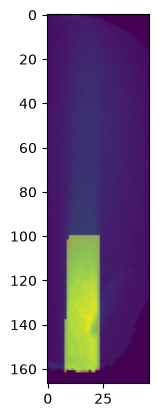

In [21]:
plt.imshow(d[18][4][40])
plt.imshow(d[18][1][40], alpha=0.5)

In [27]:
y.shape, dose.shape

(torch.Size([151, 1, 43, 45]), torch.Size([234, 1, 48, 45]))

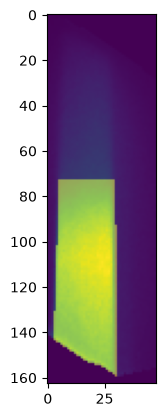

In [23]:
plt.imshow(dose.detach().cpu()[40])
plt.imshow(bev.detach().cpu()[40], alpha=0.5)

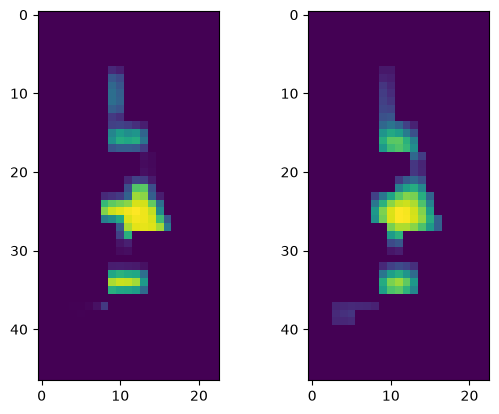

In [45]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow((y*bev).detach().cpu()[:,20])
ax[1].imshow((pred*bev).detach().cpu()[:,20])


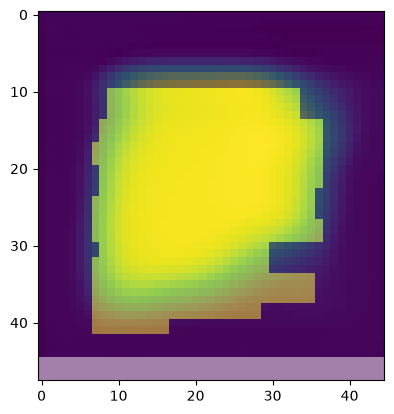

In [43]:
plt.imshow(pred.detach().cpu()[50,0])
plt.imshow(bev.detach().cpu()[50,0], alpha=0.5)

In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


# Check Data

In [ ]:
# # GT using SimpleITK

# from bev.plan import Plan
# import torch

# from concurrent.futures import ThreadPoolExecutor
# from tqdm.auto import tqdm
# import SimpleITK as sitk
# import numpy as np
# from torch.utils.data import Dataset, DataLoader
# from tqdm import tqdm

# from proton.proton_bev import rotate_image_batched
# from bev.geometry import *
# from bev.bev_torch import make_grid_5d, get_bev_torch, mm2idx, cal_scales, draw_iso_mlc

# def read_dose_parallel(file_paths, num_threads=8, scale_factor=1e5):
#     n_files = len(file_paths)

#     first_img = sitk.ReadImage(file_paths[0])
#     spatial_shape = sitk.GetArrayFromImage(first_img).shape
#     combined_array = np.zeros((n_files, *spatial_shape), dtype=np.float16)

#     def load_and_insert(idx):
#         file_path = file_paths[idx]
#         image = sitk.ReadImage(file_path)
#         # 2. Overwrite directly into the pre-allocated array
#         combined_array[idx] = (sitk.GetArrayFromImage(image) * scale_factor).astype(np.float16)

#     with ThreadPoolExecutor(max_workers=num_threads) as executor:
#         list(tqdm(executor.map(load_and_insert, range(n_files)), total=n_files, desc="Reading files"))

#     print(f"Starting parallel load with {num_threads} threads...")
#     print(f"\nFinished. Final array shape: {combined_array.shape}")
#     print(f"Data type: {combined_array.dtype}")

#     return combined_array

# class BeamData(Dataset):
#     def __init__(self, plan):
#         self.plan = plan
#         self.rot_input_tensor = torch.randn((30,)+self.plan.img.GetSize()[::-1]).to(torch.float16).cuda()
#         self.img = torch.tensor(plan.img_arr).to(torch.float16).cuda()

#         # Beam specific information
#         self.isocentre = self.plan.isocentre
#         self.n_cp = self.plan.beam_info[self.plan.beam_id]['n_cp']
#         self.sad = self.plan.beam_info[self.plan.beam_id]['sad']
#         self.cp_info = self.plan.cp[self.plan.beam_id]
#         self.angles = torch.tensor([self.cp_info[i]['ga'] for i in range(self.n_cp)]).cuda()

#         self.dose = self.load_doses()
#         self.rotate_dose()
#         self.img_rot = self.rotate_img()
#         self.bev = self.cal_bev_parallel()

#     def load_doses(self):
        
#         fl = [f'{self.plan.dose_dir}/Dose_B{self.plan.beam_id}_CP{i:03d}.mha' for i in range(self.n_cp)]
#         dose = read_dose_parallel(fl, num_threads=8)
#         dose = torch.tensor(dose)
#         return dose
    

#     def rotate_dose(self):
        
#         for i in tqdm(range(6), desc='Rotating dose'):
#             self.rot_input_tensor[:] = self.dose[30*i:(i+1)*30]
#             self.dose[30*i:(i+1)*30] = rotate_image_batched(
#                 self.rot_input_tensor,  # Shape: (D, H, W) or (1, 1, D, H, W) on GPU
#                 self.plan.img.GetSpacing(),  # Can now be a torch.Tensor or list/tuple
#                 self.plan.img.GetOrigin(),  # Can now be a torch.Tensor or list/tuple
#                 self.plan.isocentre,  # Can now be a torch.Tensor or list/tuple
#                 -self.angles[i*30:(i+1)*30],  # Can now be a torch.Tensor of angles on GPU
#                 axis="z",
#                 bg_value=0,
#                 pad_voxels=None,
#             ).cpu()

#     def rotate_img(self):
#         img_rot = torch.zeros((180,) + self.img.shape)

#         for i in tqdm(range(6), desc='Rotating image'):
#             self.rot_input_tensor[:] = self.img.expand(30, -1, -1, -1)
#             img_rot[i*30:(i+1)*30] = rotate_image_batched(
#                 self.rot_input_tensor[:],  # Shape: (D, H, W) or (1, 1, D, H, W) on GPU
#                 self.plan.img.GetSpacing(),  # Can now be a torch.Tensor or list/tuple
#                 self.plan.img.GetOrigin(),  # Can now be a torch.Tensor or list/tuple
#                 self.plan.isocentre,  # Can now be a torch.Tensor or list/tuple
#                 -self.angles[i*30:(i+1)*30],  # Can now be a torch.Tensor of angles on GPU
#                 axis="z",
#                 bg_value=-1024,
#                 pad_voxels=None,
#             ).cpu()

#         return img_rot

#     def cal_bev_parallel(self, num_threads=8):
#         combined_array = np.zeros((self.n_cp, *self.img.shape), dtype=np.uint8)
#         drawer = MLCDrawer(
#                 ref_img=self.plan.img, 
#                 isocentre=self.isocentre, 
#                 sad=self.sad
#             )
            
#         def cal_bev(idx):
#             cp = self.cp_info[idx]

#             bev = drawer.cal_bev_beam_path(
#                 mlc = MLC.get_mlc_segs_mm(cp["l"], cp["r"], self.isocentre)
#             )
            
#             combined_array[idx] = bev

#         with ThreadPoolExecutor(max_workers=num_threads) as executor:
#             list(tqdm(executor.map(cal_bev, range(self.n_cp)), total=self.n_cp, desc="Getting BEV"))

#         print(f"Starting parallel load with {num_threads} threads...")
#         print(f"\nFinished. Final array shape: {combined_array.shape}")
#         print(f"Data type: {combined_array.dtype}")

#         return torch.tensor(combined_array) 

    
        
#     def __len__(self):
#         return self.n_cp

#     def __getitem__(self, idx):
        
#         return self.doses[idx]

        



In [3]:
pat_dir = "/workspace/DoseRAD2026Dev/data/DoseRAD2026/photon/training/1ABB143"

plan = Plan(
    img_file_path=rf"{pat_dir}/image/ct.mha",
    info_json_path=rf"{pat_dir}/1ABB143.json",
    dose_dir=rf"{pat_dir}/dose",
)
print(plan.beam_info)

d = BeamData(plan)

State set to 0
OrderedDict([(0, {'sad': 1000, 'isocentre': [-7.503847563209967, -94.6958592891169, 23.400146573836572], 'n_mlc_leaf': 80, 'n_cp': 180}), (1, {'sad': 1000, 'isocentre': [-7.503847563209967, -94.6958592891169, 43.40014657383657], 'n_mlc_leaf': 80, 'n_cp': 180}), (2, {'sad': 1000, 'isocentre': [-7.503847563209967, -94.6958592891169, 63.40014657383657], 'n_mlc_leaf': 80, 'n_cp': 180})])


Reading dose files: 100%|██████████| 180/180 [00:09<00:00, 19.95it/s]


Starting parallel load with 8 threads...

Finished. Final array shape: (180, 129, 252, 276)
Data type: float16


Rotating dose & img: 100%|██████████| 6/6 [00:17<00:00,  2.85s/it]


Grid created


Calulating BEV beam path: 100%|██████████| 6/6 [00:06<00:00,  1.01s/it]


In [4]:
d.plan.isocentre_ijk

(129, 84, 76)

In [5]:
d.dose.shape

torch.Size([180, 129, 252, 276])

In [6]:
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(275.5), np.float64(251.5), np.float64(-0.5))

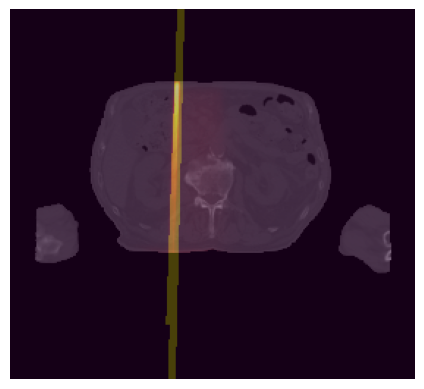

In [10]:
cp_idx = 90
plt.imshow(d.img_rot[cp_idx][73], cmap='gray')
plt.imshow(d.bev[cp_idx][73], alpha=0.4)
plt.imshow(d.dose[cp_idx][73], cmap='hot', alpha=0.3)
plt.axis('off')

(np.float64(-0.5), np.float64(275.5), np.float64(128.5), np.float64(-0.5))

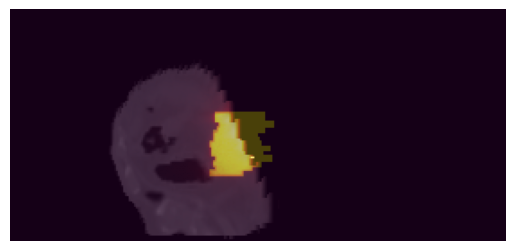

In [11]:
plt.imshow(d.img_rot[8][:,120], cmap='gray')
plt.imshow(d.bev[8][:,120], alpha=0.4)
plt.imshow(d.dose[8][:,120], cmap='hot', alpha=0.3)
plt.axis('off')

In [24]:
import SimpleITK as sitk

In [14]:
    
    img = sitk.GetImageFromArray(d.dose[90].float().numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "photon/d.nii.gz")

    img = sitk.GetImageFromArray(d.img_rot[90].float().numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "photon/ct.nii.gz")

    img = sitk.GetImageFromArray(d.bev[90].numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "photon/bev.nii.gz")


In [27]:
pwd

'/workspace/DoseRAD2026Dev/photon'

In [28]:
    
    img = sitk.GetImageFromArray(d.dose[18].float().numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "d.nii.gz")

    img = sitk.GetImageFromArray(d.img_rot[18].float().numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "ct.nii.gz")

    img = sitk.GetImageFromArray(d.bev[18].numpy())
    img.CopyInformation(d.plan.img)
    sitk.WriteImage(img, "bev.nii.gz")
